<a href="https://colab.research.google.com/github/nilsberzins/stat-405-final/blob/setara's-code/EDA405.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Connect to Database and pull data

In [ ]:
!pip install pymysql
!pip install boto3
!pip install sqlalchemy
!pip install python-dotenv
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 6.4 MB/s eta 0:00:00


In [ ]:
# package for env variables in google colab: https://pypi.org/project/colab-env/
!pip install colab-env -qU
import colab_env

  Preparing metadata (setup.py) ... done
Mounted at /content/gdrive


In [ ]:
from colab_env import envvar_handler # modify env variables in var.env file in google drive

In [ ]:
import pymysql
import sys
import boto3
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans

In [ ]:
connection = pymysql.connect(
    host=os.getenv("AWS_DATABASE_ENDPOINT"),
    user=os.getenv("AWS_USER"),
    port=int(os.getenv("AWS_PORT")),
    passwd=os.getenv("AWS_PASSWORD"),
    database=os.getenv("AWS_DBNAME")
)

In [ ]:
with connection.cursor() as cursor:
    cursor.execute("SHOW TABLES")
    tables = cursor.fetchall()

# Print table names
for table in tables:
    print(table[0])

CSU_Data_2010
CSU_Data_2011
CSU_Data_2012
CSU_Data_2013
CSU_Data_2014
CSU_Data_2015
CSU_Data_2016
CSU_Data_2017
CSU_salaries_data
Inflation_data
SuperBowl_coinTosses
UCOP_Data_2010
UCOP_Data_2011
UCOP_Data_2012
UCOP_Data_2013
UCOP_Data_2014
UCOP_Data_2015
UCOP_Data_2016
UCOP_Data_2017
UCOP_Data_2018
UCOP_Data_2019
UCOP_Data_2020
UCOP_Data_2021
UCOP_Data_2022
UCOP_Data_2023
google_elev_68sites
iris_data
nhl_goalieDate
nhl_playerDate
nhl_teamDate


**Load Data from AWS**

In [ ]:
inflation_df = pd.read_sql("SELECT * FROM Inflation_data", con=connection)
inflation_df.head()

<ipython-input-7-32a92bd7d88e>:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  inflation_df = pd.read_sql("SELECT * FROM Inflation_data", con=connection)


,row_names,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,HALF1,HALF2
0,1,2000.0,168.8,169.8,171.2,171.3,171.5,172.4,172.8,172.8,173.7,174.0,174.1,174.0,170.8,173.6
1,2,2001.0,175.1,175.8,176.2,176.9,177.7,178.0,177.5,177.5,178.3,177.7,177.4,176.7,176.6,177.5
2,3,2002.0,177.1,177.8,178.8,179.8,179.8,179.9,180.1,180.7,181.0,181.3,181.3,180.9,178.9,180.9
3,4,2003.0,181.7,183.1,184.2,183.8,183.5,183.7,183.9,184.6,185.2,185.0,184.5,184.3,183.3,184.6
4,5,2004.0,185.2,186.2,187.4,188.0,189.1,189.7,189.4,189.5,189.9,190.9,191.0,190.3,187.6,190.2


In [ ]:
# add a column which is the annual average CPI
inflation_df['annual_cpi'] = inflation_df.loc[:, 'Jan':'Dec'].mean(axis=1)
inflation_df.head()

,row_names,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,HALF1,HALF2,annual_cpi
0,1,2000.0,168.8,169.8,171.2,171.3,171.5,172.4,172.8,172.8,173.7,174.0,174.1,174.0,170.8,173.6,172.200000
1,2,2001.0,175.1,175.8,176.2,176.9,177.7,178.0,177.5,177.5,178.3,177.7,177.4,176.7,176.6,177.5,177.066667
2,3,2002.0,177.1,177.8,178.8,179.8,179.8,179.9,180.1,180.7,181.0,181.3,181.3,180.9,178.9,180.9,179.875000
3,4,2003.0,181.7,183.1,184.2,183.8,183.5,183.7,183.9,184.6,185.2,185.0,184.5,184.3,183.3,184.6,183.958333
4,5,2004.0,185.2,186.2,187.4,188.0,189.1,189.7,189.4,189.5,189.9,190.9,191.0,190.3,187.6,190.2,188.883333


In [ ]:
years = range(2010, 2017)
dfs = []

for year in years:
    query = f"""
    SELECT *
    FROM `CSU_Data_{year}`
    """
    df = pd.read_sql(query, con=connection)
    dfs.append(df)

full_data_csu = pd.concat(dfs, ignore_index=True)
full_data_csu.head()

<ipython-input-31-5d4bcbe494cc>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


,row_names,Year,EmployerType,EmployerName,DepartmentOrSubdivision,Position,ElectedOfficial,Judicial,OtherPositions,MinPositionSalary,...,HealthDentalVision,TotalRetirementAndHealthContribution,PensionFormula,EmployerURL,EmployerPopulation,LastUpdatedDate,EmployerCounty,SpecialDistrictActivities,IncludesUnfundedLiability,SpecialDistrictType
0,1,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,6482.16,14798.44,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None
1,2,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,16470.84,24556.27,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None
2,3,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,16470.84,25325.06,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None
3,4,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,6551.16,14752.03,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None
4,5,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,16018.80,23644.67,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None


In [ ]:
years = range(2010, 2024)
dfs = []

for year in years:
    query = f"""
    SELECT '{year}' AS year, location, title, `regular.pay`
    FROM `UCOP_Data_{year}`
    """
    df = pd.read_sql(query, con=connection)

    if year in [2013, 2014, 2015]:
        df = df.applymap(lambda x: x.strip("'") if isinstance(x, str) else x)

    df["year"] = df["year"].astype(int)
    df["regular.pay"] = pd.to_numeric(df["regular.pay"], errors='coerce')

    dfs.append(df)

full_data = pd.concat(dfs, ignore_index=True)
full_data.head()

<ipython-input-15-296234c0fbbc>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)
<ipython-input-15-296234c0fbbc>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)
<ipython-input-15-296234c0fbbc>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)
<ipython-input-15-296234c0fbbc>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. O

,year,location,title,regular.pay
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96
1,2010,Berkeley,GRAD STDNT RES-FULL FEE REM,5369.42
2,2010,Berkeley,TEACHING ASSISTANT - GSHIP,4802.00
3,2010,Berkeley,GRAD STDNT RES- NO REMISSION,3409.01
4,2010,Berkeley,GRAD STDNT RES-FULL FEE REM,11673.90


In [ ]:
full_data = full_data[full_data["regular.pay"]>0]

In [ ]:
full_data = full_data.dropna()

In [ ]:
full_data["location"].unique()

array(['Santa Cruz', 'Berkeley', 'DANR', 'Davis', 'Irvine', 'Los Angeles',
       'Merced', 'Riverside', 'San Diego', 'San Francisco',
       'Santa Barbara', 'UCOP', 'ASUCLA', 'Hastings College Of Law',
       'Hastings'], dtype=object)

In [ ]:
to_drop = ["San Francisco", "UCOP", "DANR", "Hastings", "Hastings College Of Law", "ASUCLA"]
full_data = full_data[~full_data["location"].isin(to_drop)]

In [ ]:
pattern = r"""(?ix)                     # (?i)=ignore-case  (?x)=verbose mode
    \b(?:                               # word-start, then one of…
        prof(?:essors?\b|\.?\b)         #  "professor" / "professors" / "prof" / "prof."
      | lect(?:urer?s?\b|\b)            #  "lecturer(s)" / "lect"
    )
"""

filtered = full_data[full_data['title'].str.contains(pattern, regex=True, na=False)]


In [ ]:
filtered = filtered[~(filtered["title"].str.contains("SUMMER"))]

In [ ]:
filtered.head()

,year,location,title,regular.pay
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96
20,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75
94,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46
175,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69
178,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78


In [ ]:
def title_assign(x):
    if "PROFL" in x or "PROFESSIONAL" in x:
        return "OTHER"
    elif "VST" in x and "ASST" in x:
        return "VST ASST"
    elif "VST" in x and "ASSOC" in x:
        return "VST ASSOC"
    elif "VST" in x:
        return "VST PROF"
    elif "ADJ" in x and "ASST" in x:
        return "ADJ ASST"
    elif ("ASOC" in x or "ASSOC" in x) and "ADJ" in x:
        return "ADJ ASOC"
    elif "ADJ" in x:
        return "ADJ PROF"
    elif ("ASST" in x or "ASSIST" in x) and "PROF" in x:
        return "ASST PROF"
    elif "ASSOC" in x and "PROF" in x:
        return "ASSOC PROF"
    elif "PROF" in x:
        return "PROF"
    elif "SR" in x and "LECT" in x:
        return "SR LECT"
    elif "LECT" in x:
        return "LECT"
    else:
        return "OTHER"

In [ ]:
filtered['prof_rank'] = (
    filtered['title']
        .str.upper()
        .fillna('')
        .apply(title_assign)
)

filtered['year'] = filtered['year'].astype(int)


filtered.head()


,year,location,title,regular.pay,prof_rank
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96,ASST PROF
20,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75,LECT
94,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46,LECT
175,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69,LECT
178,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78,LECT


In [ ]:
filtered["prof_rank"].value_counts()

,count
prof_rank,
PROF,99796
LECT,66045
ASST PROF,45946
ASSOC PROF,40005
ADJ ASST,4933
ADJ PROF,4025
ADJ ASOC,2745
SR LECT,2209
VST ASST,529


In [ ]:
avg_salary = (
    filtered
      .groupby(['prof_rank', 'location'], as_index=False)
      .agg(avg_regular_pay=('regular.pay', 'mean'))
)

avg_salary


,prof_rank,location,avg_regular_pay
0,ADJ ASOC,Berkeley,76209.988050
1,ADJ ASOC,Davis,78069.147082
2,ADJ ASOC,Irvine,75783.453233
3,ADJ ASOC,Los Angeles,81951.866162
4,ADJ ASOC,Riverside,83422.896552
...,...,...,...
90,VST PROF,Los Angeles,26274.428080
91,VST PROF,Riverside,14328.400000
92,VST PROF,San Diego,26011.854286
93,VST PROF,Santa Barbara,24105.281000


adding more features

In [ ]:
inflation_df['Year'] = inflation_df['Year'].astype(int)
cpi_df = inflation_df[['Year', 'annual_cpi']]
cpi_df.columns = ['year', 'annual_cpi']
cpi_df.head()

,year,annual_cpi
0,2000,172.200000
1,2001,177.066667
2,2002,179.875000
3,2003,183.958333
4,2004,188.883333


In [ ]:
# add one feature - annual cpi for every year
uc_df_enhanced = filtered.merge(cpi_df, on='year')
uc_df_enhanced

,year,location,title,regular.pay,prof_rank,annual_cpi
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96,ASST PROF,218.055500
1,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75,LECT,218.055500
2,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46,LECT,218.055500
3,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69,LECT,218.055500
4,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78,LECT,218.055500
...,...,...,...,...,...,...
266803,2023,San Diego,PROF IN RES-HCOMP,30330.00,PROF,304.701583
266804,2023,Merced,ASST PROF-AY,104433.00,ASST PROF,304.701583
266805,2023,Santa Cruz,ASST PROF-AY,98567.00,ASST PROF,304.701583
266806,2023,Berkeley,LECT-AY-CONTINUING,92865.00,LECT,304.701583


In [ ]:
enroll_df = pd.read_csv('EnrollmentUC.csv')
enroll_df = enroll_df[['Year', 'Campus', 'Enrollees']]
enroll_df.columns = ['year', 'location', 'enrollees']
enroll_df = enroll_df[enroll_df['year'] != 2024] # remove because we don't have salary UC data for 2024
# enroll_df.set_index(["year", "location"], inplace=True, drop=True) # create multi-index
enroll_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'EnrollmentUC.csv'

In [ ]:
# add another feature - enrollment number unique to the combo of year & location
uc_df_enhanced = uc_df_enhanced.merge(enroll_df, on=['year', 'location'])
uc_df_enhanced

,year,location,title,regular.pay,prof_rank,annual_cpi,enrollees
0,2018,Berkeley,LECT-FY,13721.0,LECT,251.106833,6012
1,2018,Berkeley,LECT-AY-1/10,15384.0,LECT,251.106833,6012
2,2018,Berkeley,LECT-FY,9373.0,LECT,251.106833,6012
3,2018,Berkeley,LECT-AY-1/10,15216.0,LECT,251.106833,6012
4,2018,Berkeley,LECT-AY-1/10,5513.0,LECT,251.106833,6012
...,...,...,...,...,...,...,...
125757,2023,San Diego,PROF IN RES-HCOMP,30330.0,PROF,304.701583,7005
125758,2023,Merced,ASST PROF-AY,104433.0,ASST PROF,304.701583,2416
125759,2023,Santa Cruz,ASST PROF-AY,98567.0,ASST PROF,304.701583,4381
125760,2023,Berkeley,LECT-AY-CONTINUING,92865.0,LECT,304.701583,6641


some plots

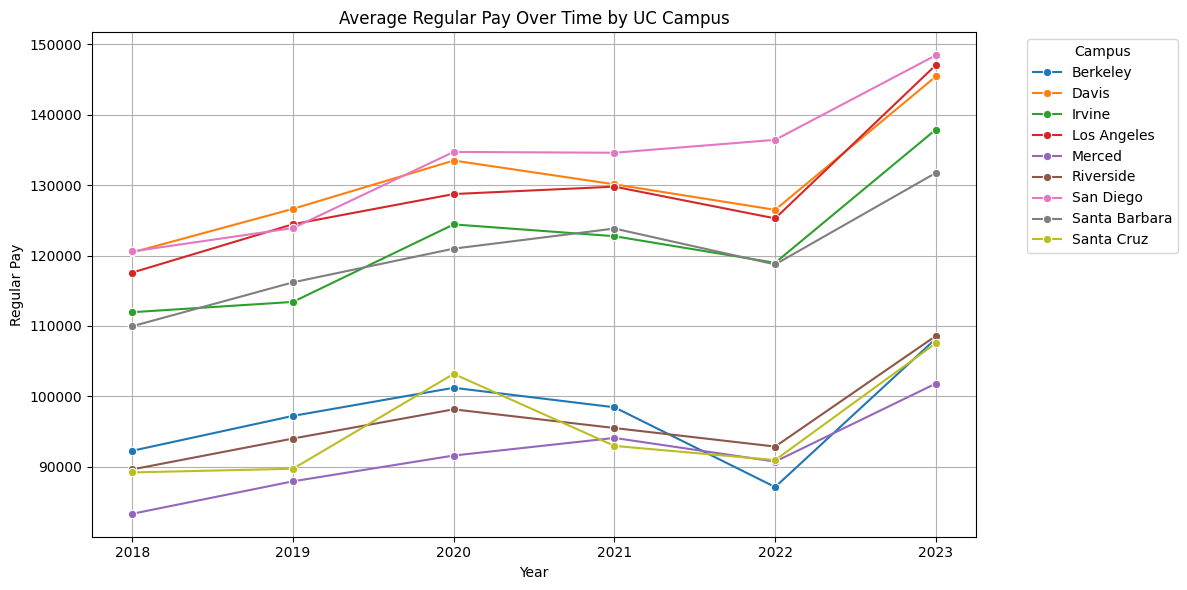

In [ ]:
#time trend analysis plot by campus
avg_by_campus = filtered.groupby(['year', 'location'])['regular.pay'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_by_campus, x='year', y='regular.pay', hue='location', marker="o")

plt.title("Average Regular Pay Over Time by UC Campus")
plt.ylabel("Regular Pay")
plt.xlabel("Year")
plt.legend(title='Campus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

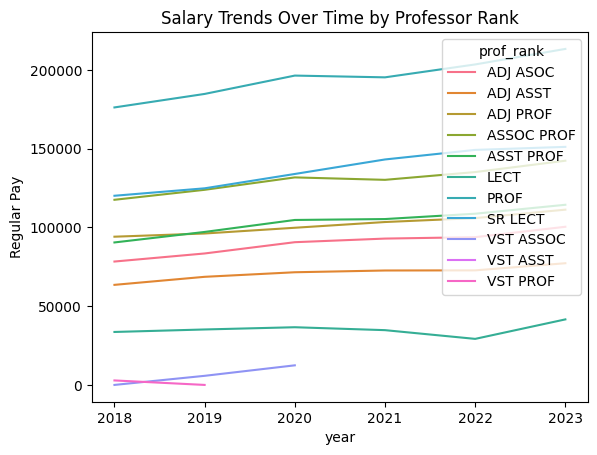

In [ ]:
# By Rank
avg_rank = filtered.groupby(['year', 'prof_rank'])['regular.pay'].mean().reset_index()
sns.lineplot(data=avg_rank, x='year', y='regular.pay', hue='prof_rank')
plt.title("Salary Trends Over Time by Professor Rank")
plt.ylabel("Regular Pay")
plt.show()

In [ ]:
#want to see if there are disparities
summary = filtered.groupby(['year', 'prof_rank'])['regular.pay'].agg(['count', 'mean', 'median']).reset_index()
summary.head()


,year,prof_rank,count,mean,median
0,2018,ADJ ASOC,190,78354.642105,93829.0
1,2018,ADJ ASST,421,63548.446556,67167.0
2,2018,ADJ PROF,298,94131.117450,88176.5
3,2018,ASSOC PROF,3041,117566.101282,115966.0
4,2018,ASST PROF,3898,90478.310672,95426.0


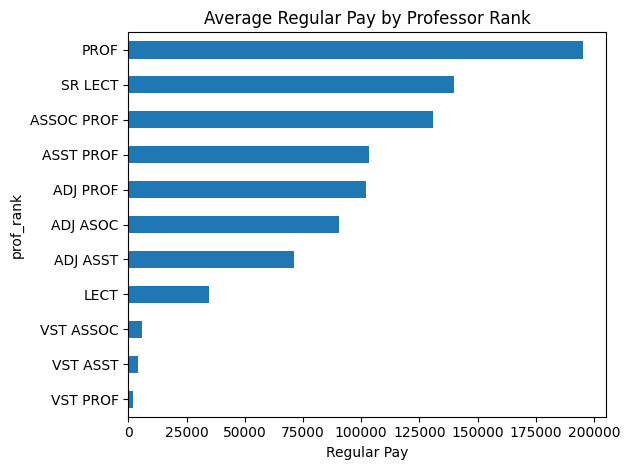

In [ ]:
#looking by position
filtered.groupby('prof_rank')['regular.pay'].mean().sort_values().plot(kind='barh')
plt.title("Average Regular Pay by Professor Rank")
plt.xlabel("Regular Pay")
plt.tight_layout()
plt.show()


***Statistical Analysis***

assumptions for 2-sample t-test

Whether the two samples data groups are independent.

Whether the data elements in respective groups follow any normal distribution.

Whether the given two samples have similar variances. This assumption is also known as the homogeneity assumption.

<Axes: xlabel='regular.pay', ylabel='Count'>

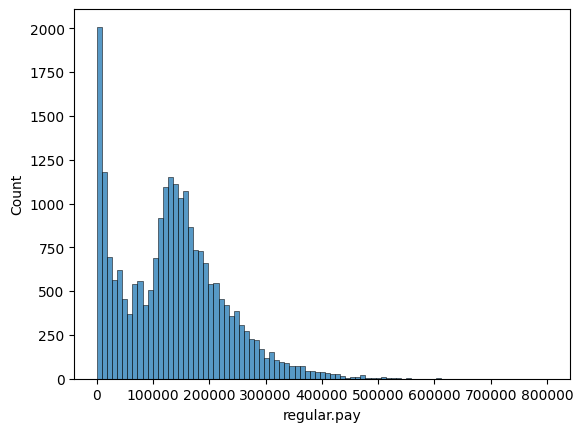

In [ ]:
sns.histplot(filtered[filtered['year'] == 2023], x='regular.pay')

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-34-60d9dbf0d58e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hist_data['regular.pay'] = np.log(hist_data['regular.pay'])


<Axes: xlabel='regular.pay', ylabel='Count'>

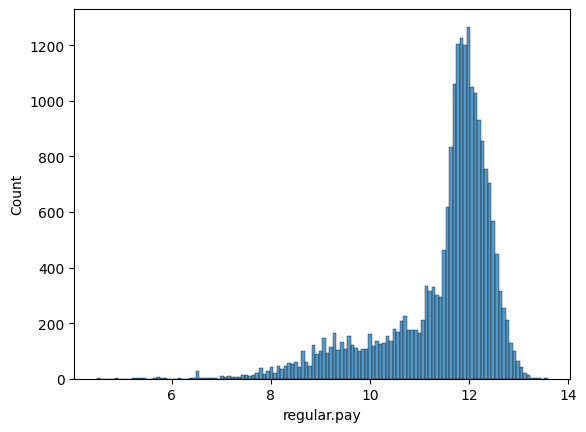

In [ ]:
# check assumptions
# visualize spread of salaries for the year 2023, log transform makes it normal ish

hist_data = filtered[filtered['year'] == 2023]
hist_data['regular.pay'] = np.log(hist_data['regular.pay'])
sns.histplot(hist_data, x='regular.pay')

In [ ]:
# determine variance
hist_data['regular.pay'].value_counts()
filtered['regular.pay'].value_counts()
# print(np.var(hist_data['regular.pay']))

,count
regular.pay,
0.0,5287
6202.0,81
132183.0,78
140300.0,77
6021.0,74
...,...
52191.0,1
79412.0,1
35304.0,1


MODELING

**clustering**

In [ ]:
uc_df_enhanced

,year,location,title,regular.pay,prof_rank,annual_cpi,enrollees
0,2018,Berkeley,LECT-FY,13721.0,LECT,251.106833,6012
1,2018,Berkeley,LECT-AY-1/10,15384.0,LECT,251.106833,6012
2,2018,Berkeley,LECT-FY,9373.0,LECT,251.106833,6012
3,2018,Berkeley,LECT-AY-1/10,15216.0,LECT,251.106833,6012
4,2018,Berkeley,LECT-AY-1/10,5513.0,LECT,251.106833,6012
...,...,...,...,...,...,...,...
125757,2023,San Diego,PROF IN RES-HCOMP,30330.0,PROF,304.701583,7005
125758,2023,Merced,ASST PROF-AY,104433.0,ASST PROF,304.701583,2416
125759,2023,Santa Cruz,ASST PROF-AY,98567.0,ASST PROF,304.701583,4381
125760,2023,Berkeley,LECT-AY-CONTINUING,92865.0,LECT,304.701583,6641


In [ ]:
# one hot encode variables
cat_vars = pd.get_dummies(uc_df_enhanced[['location', 'prof_rank']])
cat_vars

,location_Berkeley,location_Davis,location_Irvine,location_Los Angeles,location_Merced,location_Riverside,location_San Diego,location_Santa Barbara,location_Santa Cruz,prof_rank_ADJ ASOC,prof_rank_ADJ ASST,prof_rank_ADJ PROF,prof_rank_ASSOC PROF,prof_rank_ASST PROF,prof_rank_LECT,prof_rank_PROF,prof_rank_SR LECT,prof_rank_VST ASSOC,prof_rank_VST ASST,prof_rank_VST PROF
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125757,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
125758,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
125759,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False
125760,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


In [ ]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(uc_df_enhanced)

**random forest**

In [ ]:
#random forest
X = filtered[['year', 'location', 'prof_rank']]
y = filtered['regular.pay']

# Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['location', 'prof_rank'])
], remainder='passthrough')

# Model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
print("R² score:", pipeline.score(X_test, y_test))
# baseline random forest score: R² score: 0.5683763136647576

R² score: 0.5683763136647576


In [ ]:
#checking feature importance
importances = pipeline.named_steps['model'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
15,cat__prof_rank_PROF,0.695058
14,cat__prof_rank_LECT,0.226080
20,remainder__year,0.020130
3,cat__location_Los Angeles,0.017904
12,cat__prof_rank_ASSOC PROF,0.017275
5,cat__location_Riverside,0.004923
10,cat__prof_rank_ADJ ASST,0.004233
16,cat__prof_rank_SR LECT,0.003491
0,cat__location_Berkeley,0.001998
8,cat__location_Santa Cruz,0.001848


In [ ]:
#mse and mae for randomforest model
y_pred = pipeline.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


MAE: 40032.89258114064
RMSE: 56973.15221971202


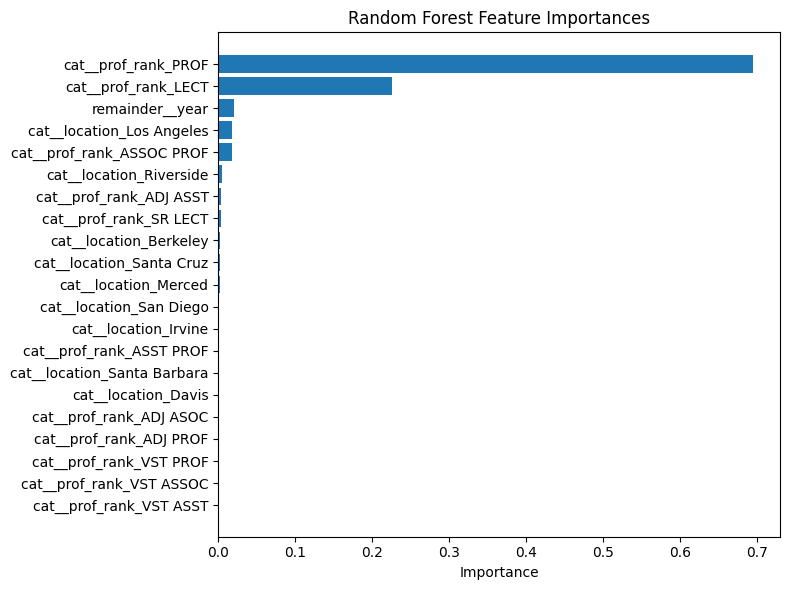

In [ ]:
#feature importance plot
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_

# Create DataFrame
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values(by='importance', ascending=True)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(feat_df['feature'], feat_df['importance'])
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

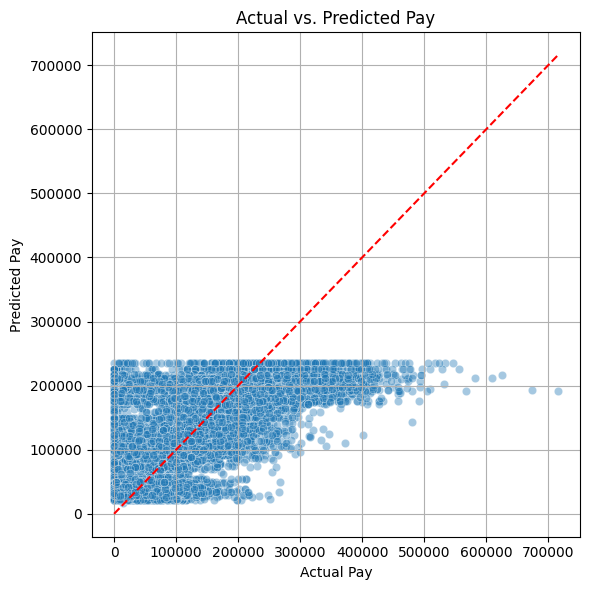

In [ ]:
#prediction plot
y_pred = pipeline.predict(X_test)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel("Actual Pay")
plt.ylabel("Predicted Pay")
plt.title("Actual vs. Predicted Pay")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# random forest with enhanced dataset, predicting regular pay for professors/lecturers etc
# R² score: 0.5728963996420944, doesn't improve much from baseline model
X = uc_df_enhanced[['year', 'location', 'prof_rank', 'annual_cpi', 'enrollees']]
y = uc_df_enhanced['regular.pay']

# Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['location', 'prof_rank'])
], remainder='passthrough')

# Model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, random_state=1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
pipeline.fit(X_train, y_train)
print("R² score:", pipeline.score(X_test, y_test))

R² score: 0.5728963996420944


In [ ]:
#checking feature importance
importances = pipeline.named_steps['model'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
15,cat__prof_rank_PROF,0.695074
14,cat__prof_rank_LECT,0.224931
12,cat__prof_rank_ASSOC PROF,0.017403
3,cat__location_Los Angeles,0.017145
22,remainder__enrollees,0.009482
20,remainder__year,0.009461
21,remainder__annual_cpi,0.008648
10,cat__prof_rank_ADJ ASST,0.004438
16,cat__prof_rank_SR LECT,0.003626
5,cat__location_Riverside,0.002933


conclusion - prof vs. lecture is a big disparity, title matters most when predicting pay

In [ ]:
#time series prophet

# Group to get annual UC-wide average pay
df_avg = filtered.groupby('year')['regular.pay'].mean().reset_index()
df_avg['ds'] = pd.to_datetime(df_avg['year'], format='%Y')  # Prophet needs datetime
df_avg = df_avg.rename(columns={'regular.pay': 'y'})[['ds', 'y']]

model = Prophet()
model.fit(df_avg)

# Forecast 5 years into the future
future = model.make_future_dataframe(periods=5, freq='Y')
forecast = model.predict(future)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/03_998t0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/tf9735iw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29771', 'data', 'file=/tmp/tmplcqx2800/03_998t0.json', 'init=/tmp/tmplcqx2800/tf9735iw.json', 'output', 'file=/tmp/tmplcqx2800/prophet_modelx0_xwio7/prophet_model-20250607045018.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

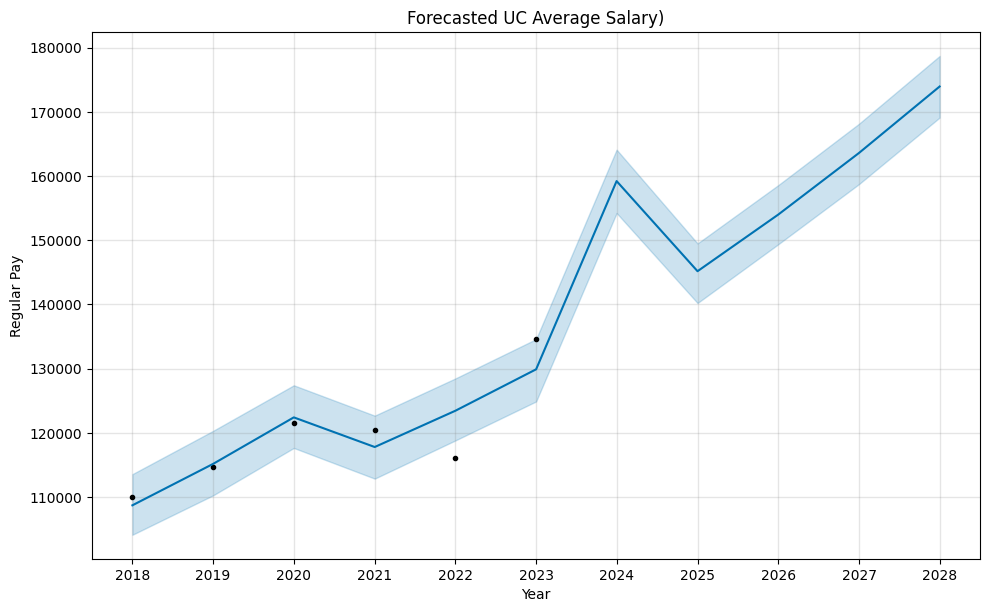

In [ ]:
model.plot(forecast)
plt.title("Forecasted UC Average Salary)")
plt.ylabel("Regular Pay")
plt.xlabel("Year")
plt.grid(True)
plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/g9p7xnwe.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/bnrsmxx_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19960', 'data', 'file=/tmp/tmplcqx2800/g9p7xnwe.json', 'init=/tmp/tmplcqx2800/bnrsmxx_.json', 'output', 'file=/tmp/tmplcqx2800/prophet_modelif3u5sca/prophet_model-20250607045018.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

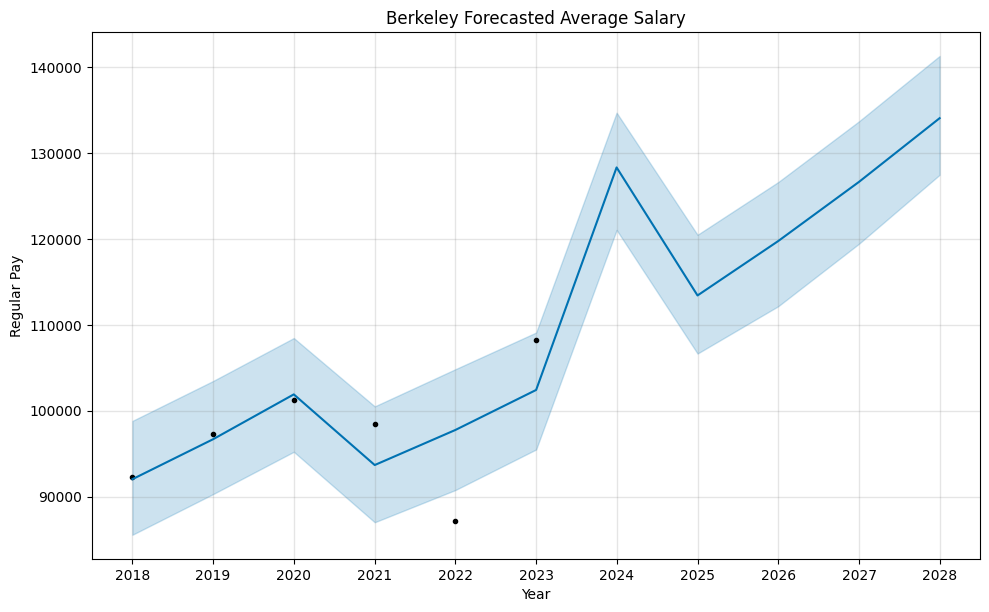

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/gkdv39zh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/0yvrncfw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=30214', 'data', 'file=/tmp/tmplcqx2800/gkdv39zh.json', 'init=/tmp/tmplcqx2800/0yvrncfw.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model7zcakcfg/prophet_model-20250607045018.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

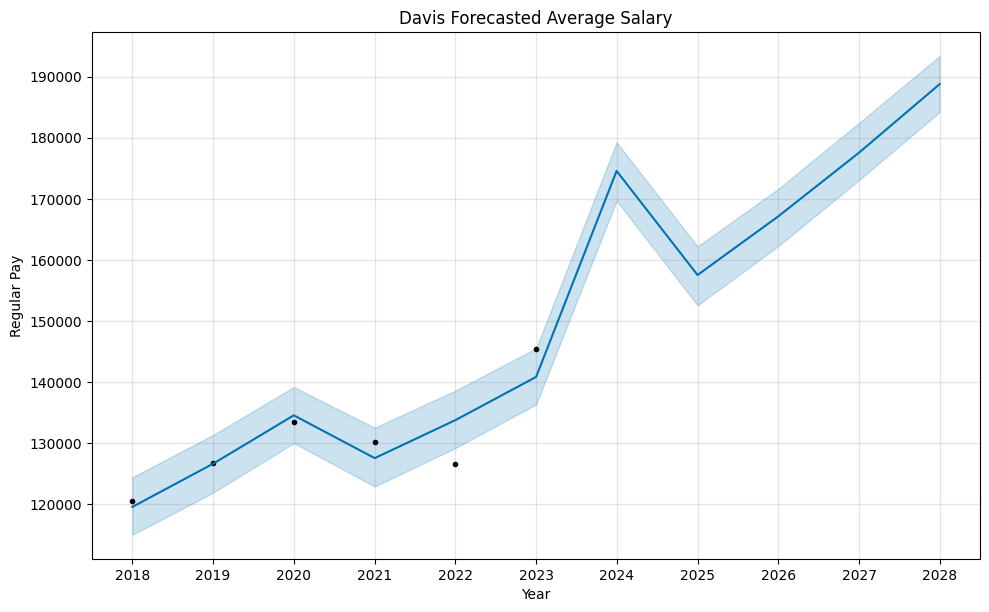

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/w3w3i6d8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/hqd5aig_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24616', 'data', 'file=/tmp/tmplcqx2800/w3w3i6d8.json', 'init=/tmp/tmplcqx2800/hqd5aig_.json', 'output', 'file=/tmp/tmplcqx2800/prophet_modelibl5991i/prophet_model-20250607045019.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

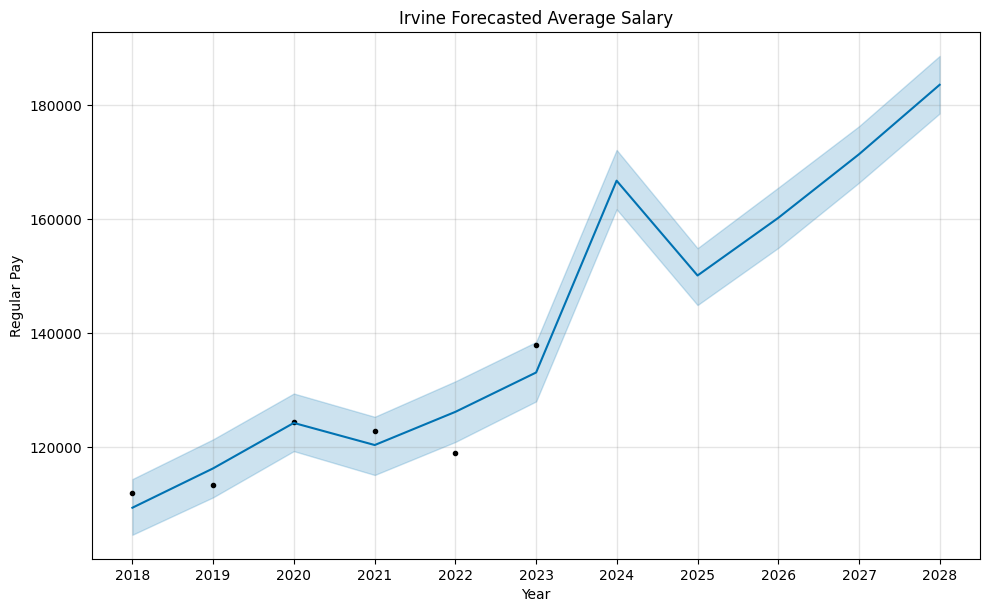

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/jn3ls41y.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/5fnp03n6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=40266', 'data', 'file=/tmp/tmplcqx2800/jn3ls41y.json', 'init=/tmp/tmplcqx2800/5fnp03n6.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model_wt_sltb/prophet_model-20250607045019.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

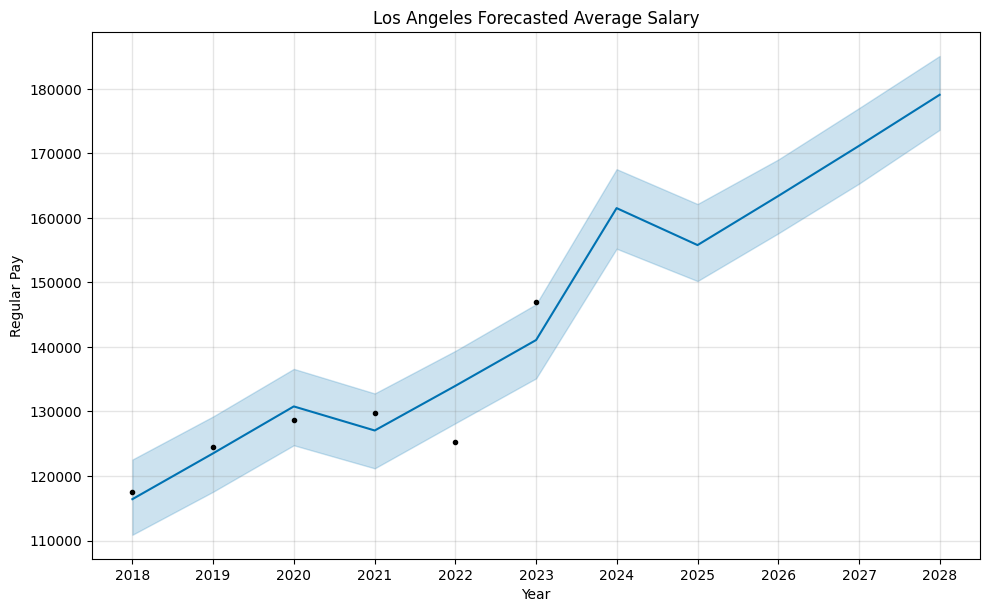

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/qepp3jc2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/mipqhz1l.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=33332', 'data', 'file=/tmp/tmplcqx2800/qepp3jc2.json', 'init=/tmp/tmplcqx2800/mipqhz1l.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model9q3tzovg/prophet_model-20250607045020.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

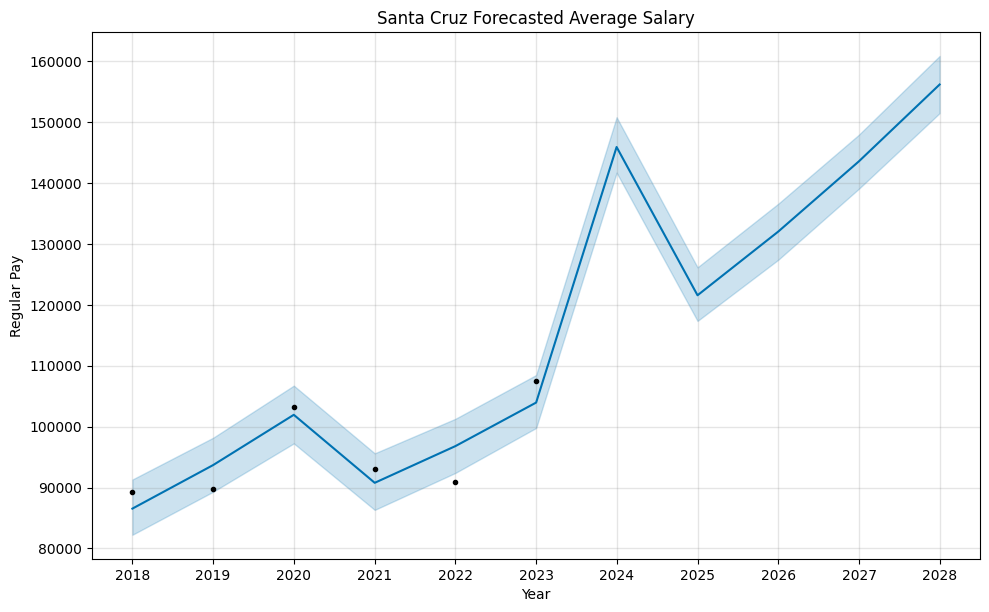

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/t5z8egt0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/7he9_rap.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36290', 'data', 'file=/tmp/tmplcqx2800/t5z8egt0.json', 'init=/tmp/tmplcqx2800/7he9_rap.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model43kf9w33/prophet_model-20250607045020.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

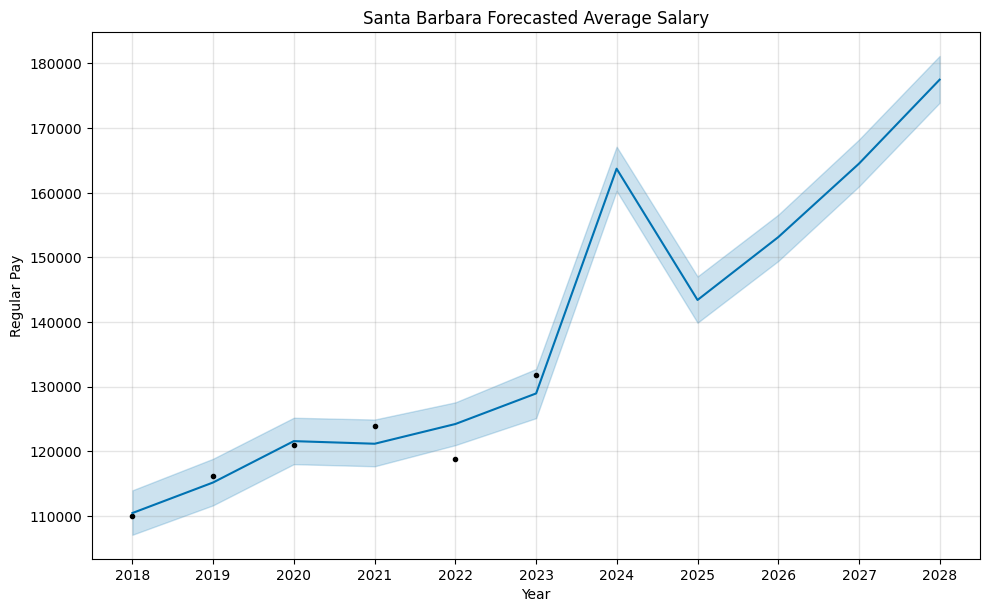

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/ynr791s6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/grn4e0z7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94098', 'data', 'file=/tmp/tmplcqx2800/ynr791s6.json', 'init=/tmp/tmplcqx2800/grn4e0z7.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model1lbaw3rk/prophet_model-20250607045020.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

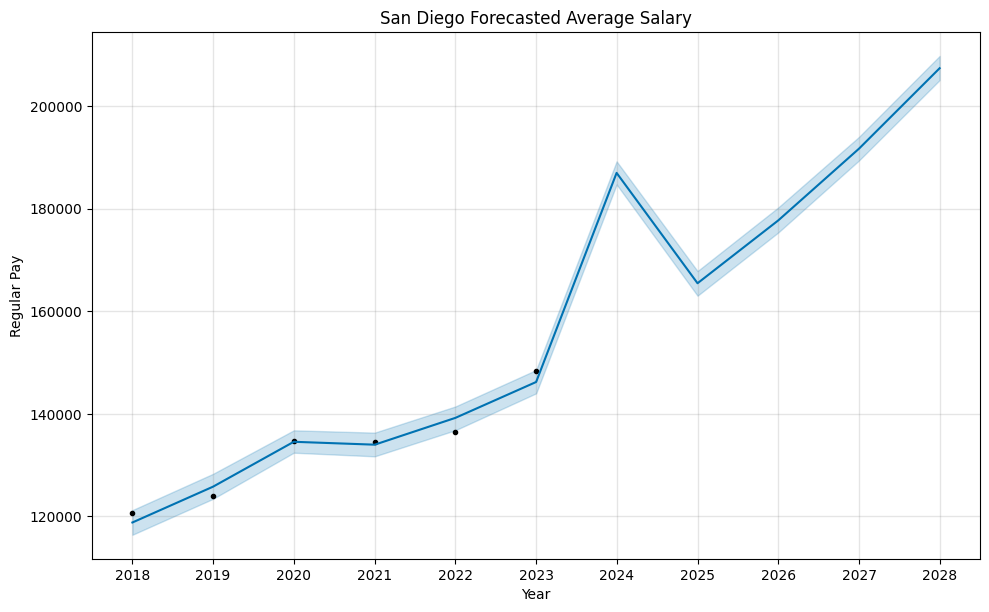

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/6gnupv82.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/3o42dr23.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95168', 'data', 'file=/tmp/tmplcqx2800/6gnupv82.json', 'init=/tmp/tmplcqx2800/3o42dr23.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model4484_t2i/prophet_model-20250607045021.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

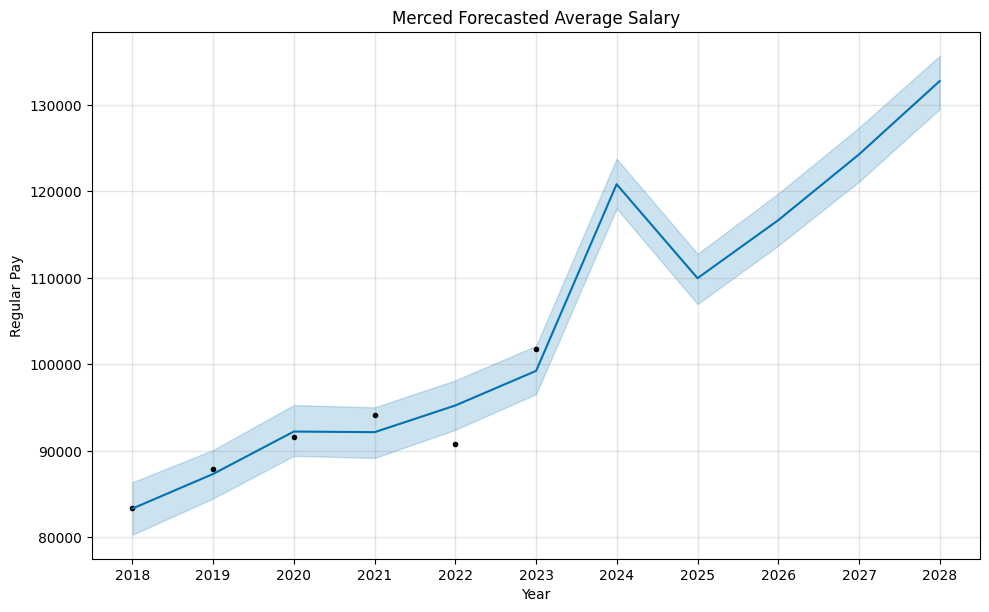

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/jfwfh8e7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/xlpkbu_y.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=64424', 'data', 'file=/tmp/tmplcqx2800/jfwfh8e7.json', 'init=/tmp/tmplcqx2800/xlpkbu_y.json', 'output', 'file=/tmp/tmplcqx2800/prophet_modelhq46aa_3/prophet_model-20250607045021.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

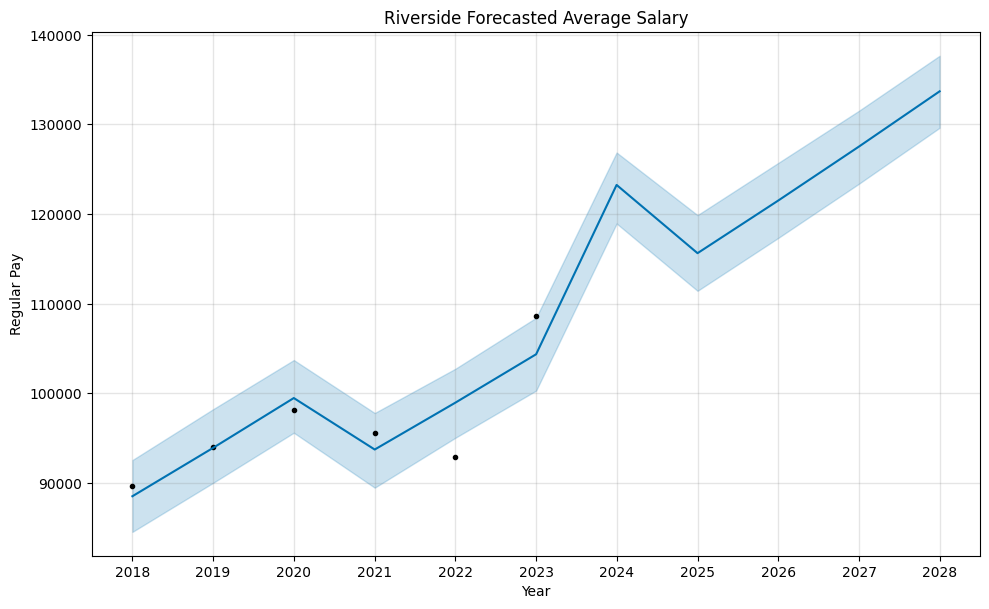

In [ ]:
#campus specific
for campus in filtered['location'].unique():
    df_campus = filtered[filtered['location'] == campus]
    df_avg = df_campus.groupby('year')['regular.pay'].mean().reset_index()
    df_avg['ds'] = pd.to_datetime(df_avg['year'], format='%Y')
    df_avg = df_avg.rename(columns={'regular.pay': 'y'})[['ds', 'y']]

    if len(df_avg) < 5:
        continue  # skip if not enough data

    model = Prophet()
    model.fit(df_avg)

    future = model.make_future_dataframe(periods=5, freq='Y')
    forecast = model.predict(future)

    model.plot(forecast)
    plt.title(f"{campus} Forecasted Average Salary")
    plt.ylabel("Regular Pay")
    plt.xlabel("Year")
    plt.show()
